In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
data = df[['PassengerId', 'Survived', 'Pclass', 'Name',
           'Sex', 'Age', 'SibSp', 'Parch',
           'Fare', 'Embarked']].copy()

In [26]:
data.columns = ['passenger_id', 'survived', 'passenger_class',
                'name', 'gender', 'age',
                'siblings_spouses', 'parents_children',
                'fare', 'embarked']

data.head()

,passenger_id,survived,passenger_class,name,gender,age,siblings_spouses,parents_children,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [27]:
duplicates = data[data.duplicated()]
duplicates

,passenger_id,survived,passenger_class,name,gender,age,siblings_spouses,parents_children,fare,embarked


In [28]:
data = data.drop(columns='passenger_id')

In [29]:
data.head()

,survived,passenger_class,name,gender,age,siblings_spouses,parents_children,fare,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [30]:
data.isnull().sum()

,0
survived,0
passenger_class,0
name,0
gender,0
age,177
siblings_spouses,0
parents_children,0
fare,0
embarked,2


In [32]:
data['age'] = data['age'].fillna(data['age'].median())

In [33]:
data = data.dropna()

In [23]:
data.isnull().sum()

,0
survived,0
passenger_class,0
name,0
gender,0
age,0
siblings_spouses,0
parents_children,0
fare,0
embarked,2


In [34]:
numerical = [
    'age',
    'fare',
    'siblings_spouses',
    'parents_children',
    'passenger_class'
]

data[numerical].describe()

,age,fare,siblings_spouses,parents_children,passenger_class
count,889.000000,889.000000,889.000000,889.000000,889.000000
mean,29.315152,32.096681,0.524184,0.382452,2.311586
std,12.984932,49.697504,1.103705,0.806761,0.834700
min,0.420000,0.000000,0.000000,0.000000,1.000000
25%,22.000000,7.895800,0.000000,0.000000,2.000000
50%,28.000000,14.454200,0.000000,0.000000,3.000000
75%,35.000000,31.000000,1.000000,0.000000,3.000000
max,80.000000,512.329200,8.000000,6.000000,3.000000


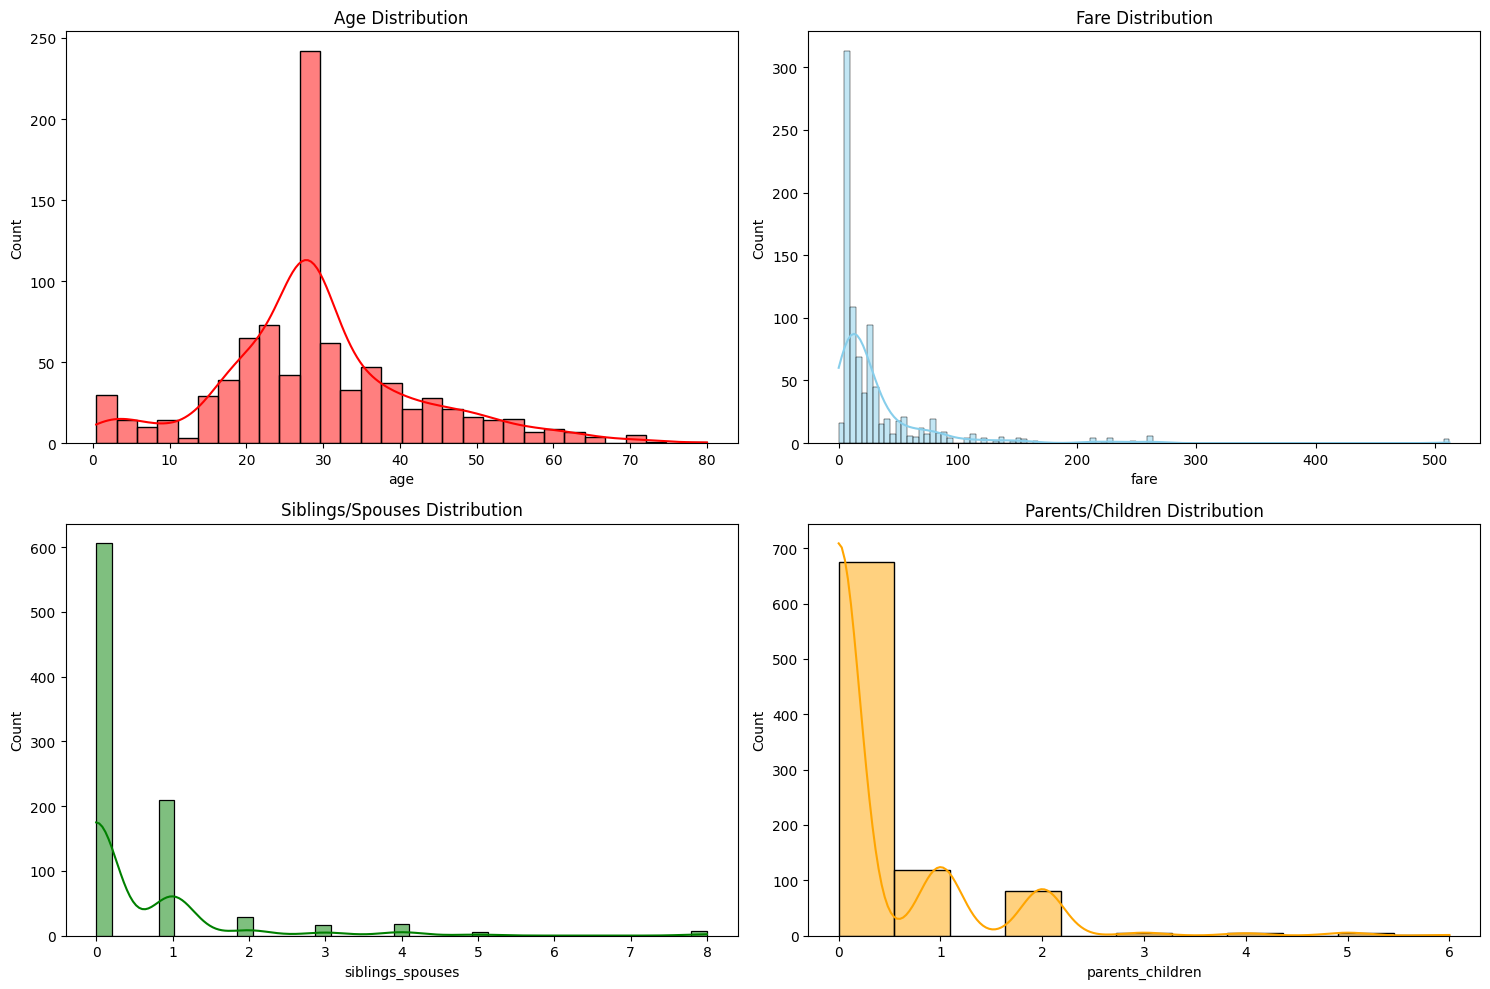

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=data, x='age', kde=True, color='red', ax=axs[0,0])
axs[0,0].set_title('Age Distribution')

sns.histplot(data=data, x='fare', kde=True, color='skyblue', ax=axs[0,1])
axs[0,1].set_title('Fare Distribution')

sns.histplot(data=data, x='siblings_spouses', kde=True, color='green', ax=axs[1,0])
axs[1,0].set_title('Siblings/Spouses Distribution')

sns.histplot(data=data, x='parents_children', kde=True, color='orange', ax=axs[1,1])
axs[1,1].set_title('Parents/Children Distribution')

plt.tight_layout()
plt.show()

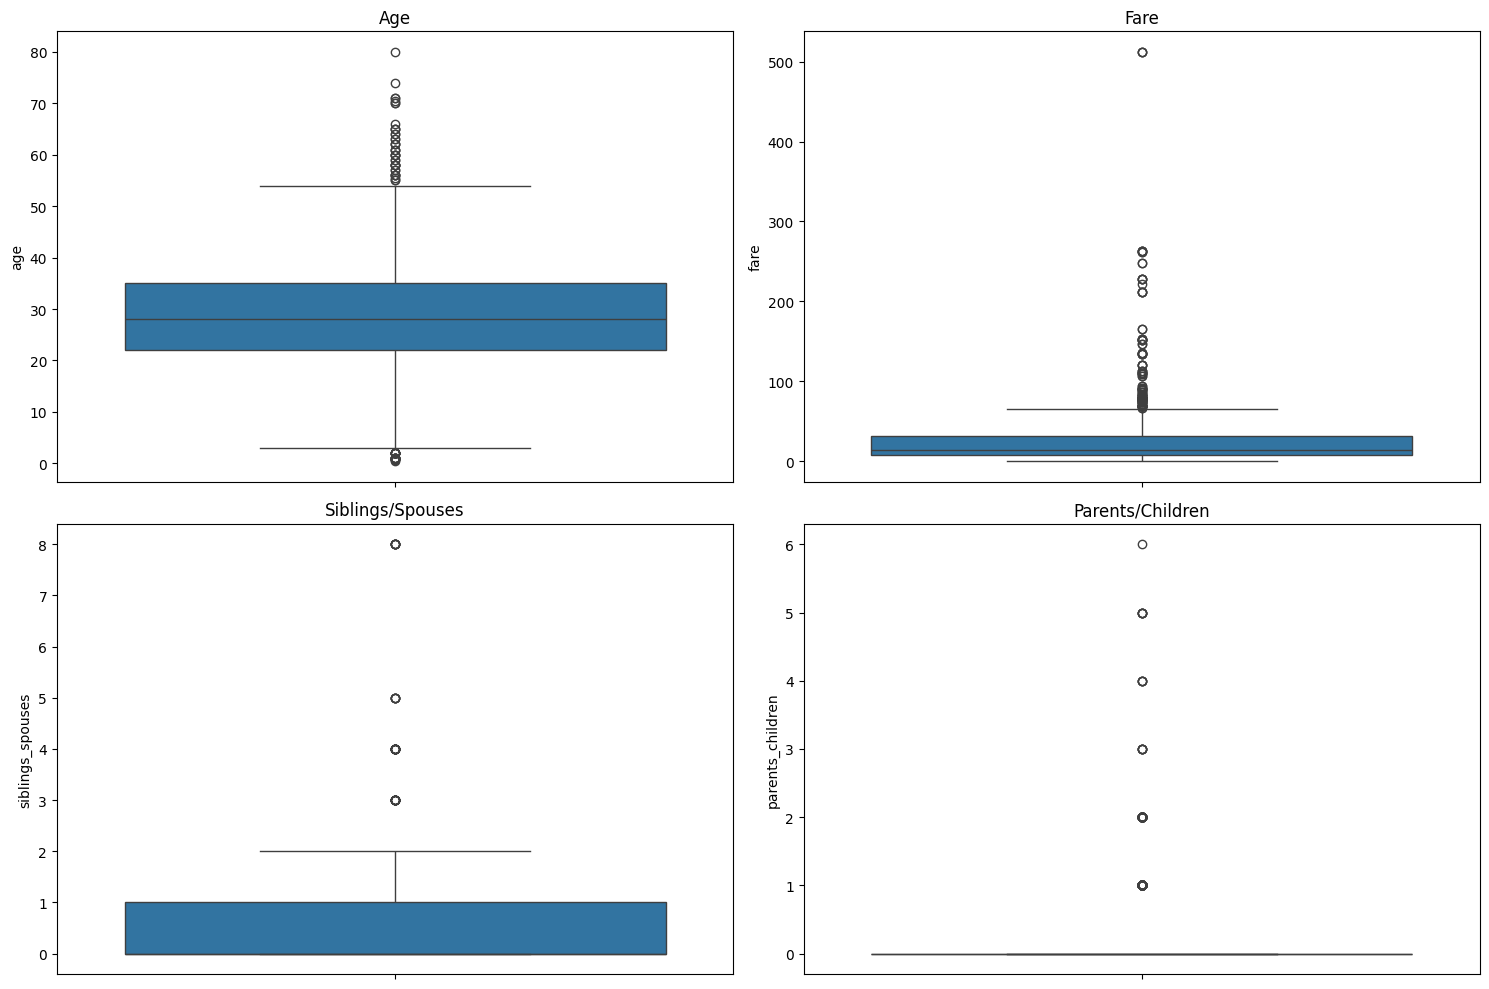

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(y=data['age'], ax=axs[0,0])
axs[0,0].set_title("Age")

sns.boxplot(y=data['fare'], ax=axs[0,1])
axs[0,1].set_title("Fare")

sns.boxplot(y=data['siblings_spouses'], ax=axs[1,0])
axs[1,0].set_title("Siblings/Spouses")

sns.boxplot(y=data['parents_children'], ax=axs[1,1])
axs[1,1].set_title("Parents/Children")

plt.tight_layout()
plt.show()

In [38]:
# Calculate Q1, Median, Q3
q1, q2, q3 = np.percentile(data['fare'], [25, 50, 75])

# IQR
iqr = q3 - q1

# Lower and Upper limits
lower = q1 - (1.5 * iqr)
upper = q3 + (1.5 * iqr)

# Remove outliers
data = data[(data['fare'] >= lower) & (data['fare'] <= upper)]

In [39]:
q1, q2, q3 = np.percentile(data['age'], [25, 50, 75])

iqr = q3 - q1

lower = q1 - (1.5 * iqr)
upper = q3 + (1.5 * iqr)

data = data[(data['age'] >= lower) & (data['age'] <= upper)]

In [40]:
data.shape

(685, 9)

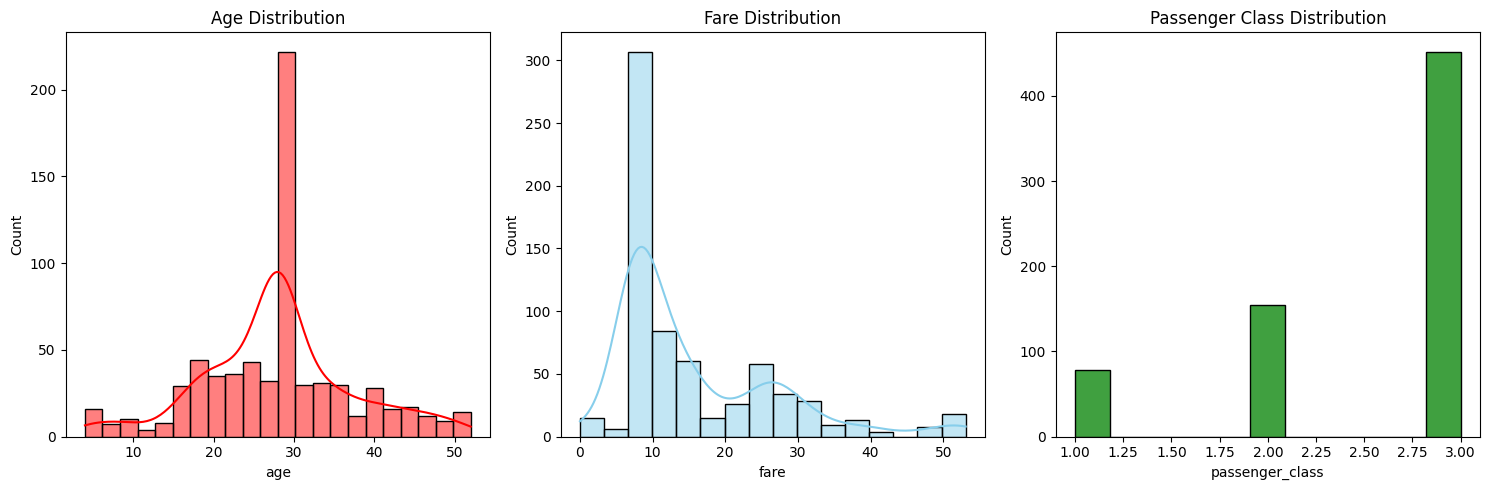

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=data, x='age', kde=True, color='red', ax=axs[0])
axs[0].set_title("Age Distribution")

sns.histplot(data=data, x='fare', kde=True, color='skyblue', ax=axs[1])
axs[1].set_title("Fare Distribution")

sns.histplot(data=data, x='passenger_class', kde=False, color='green', ax=axs[2])
axs[2].set_title("Passenger Class Distribution")

plt.tight_layout()
plt.show()

In [42]:
data.head(20)

,survived,passenger_class,name,gender,age,siblings_spouses,parents_children,fare,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
5,0,3,"Moran, Mr. James",male,28.0,0,0,8.4583,Q
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,11.1333,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,30.0708,C
10,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,16.7000,S
12,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,8.0500,S
13,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,31.2750,S


In [43]:
data['survived'].value_counts()

,count
survived,
0,468
1,217


In [46]:
data['survived'] = data['survived'].replace({
    0: 'No',
    1: 'Yes'
})

In [47]:
data['gender'].value_counts()

,count
gender,
male,468
female,217


In [48]:
data['gender'] = data['gender'].replace({
    1: 'male',
    2: 'female'
})


In [49]:
data['passenger_class'].value_counts()


,count
passenger_class,
3,452
2,155
1,78


In [50]:
data['passenger_class'] = data['passenger_class'].replace({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})

In [51]:
data['passenger_class'].value_counts()


,count
passenger_class,
Third Class,452
Second Class,155
First Class,78


In [52]:
categorical = data[['survived', 'gender', 'passenger_class', 'embarked']]

categorical.head()

,survived,gender,passenger_class,embarked
0,No,male,Third Class,Southampton
2,Yes,female,Third Class,Southampton
3,Yes,female,First Class,Southampton
4,No,male,Third Class,Southampton
5,No,male,Third Class,Queenstown


In [55]:
numerical = data[['age',
                  'fare',
                  'siblings_spouses',
                  'parents_children']]
numerical.head()


,age,fare,siblings_spouses,parents_children
0,22.0,7.2500,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0
5,28.0,8.4583,0,0


In [56]:
skew_limit = 0.75
skew_vals = numerical.skew()
skew_vals

,0
age,0.097243
fare,1.438756
siblings_spouses,2.956034
parents_children,3.455206


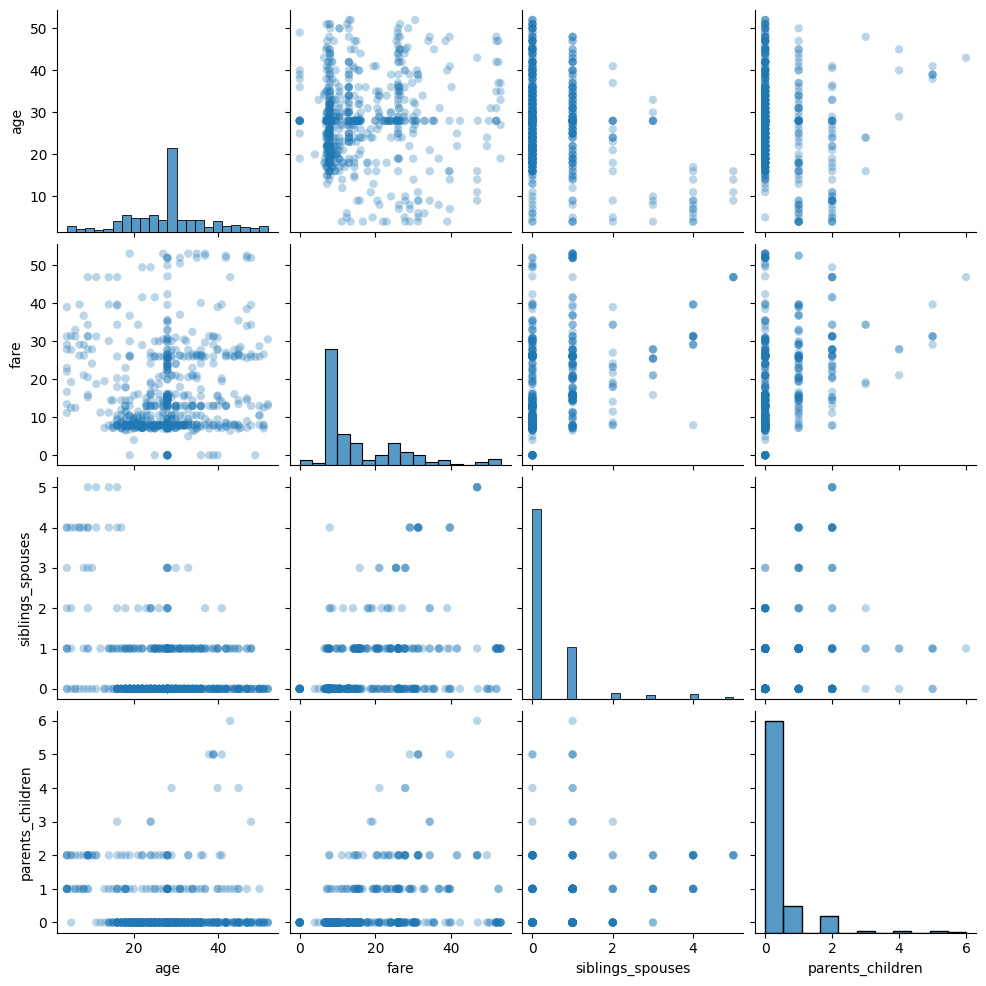

In [57]:
sns.pairplot(numerical,
             plot_kws=dict(alpha=0.3, edgecolor='none'))

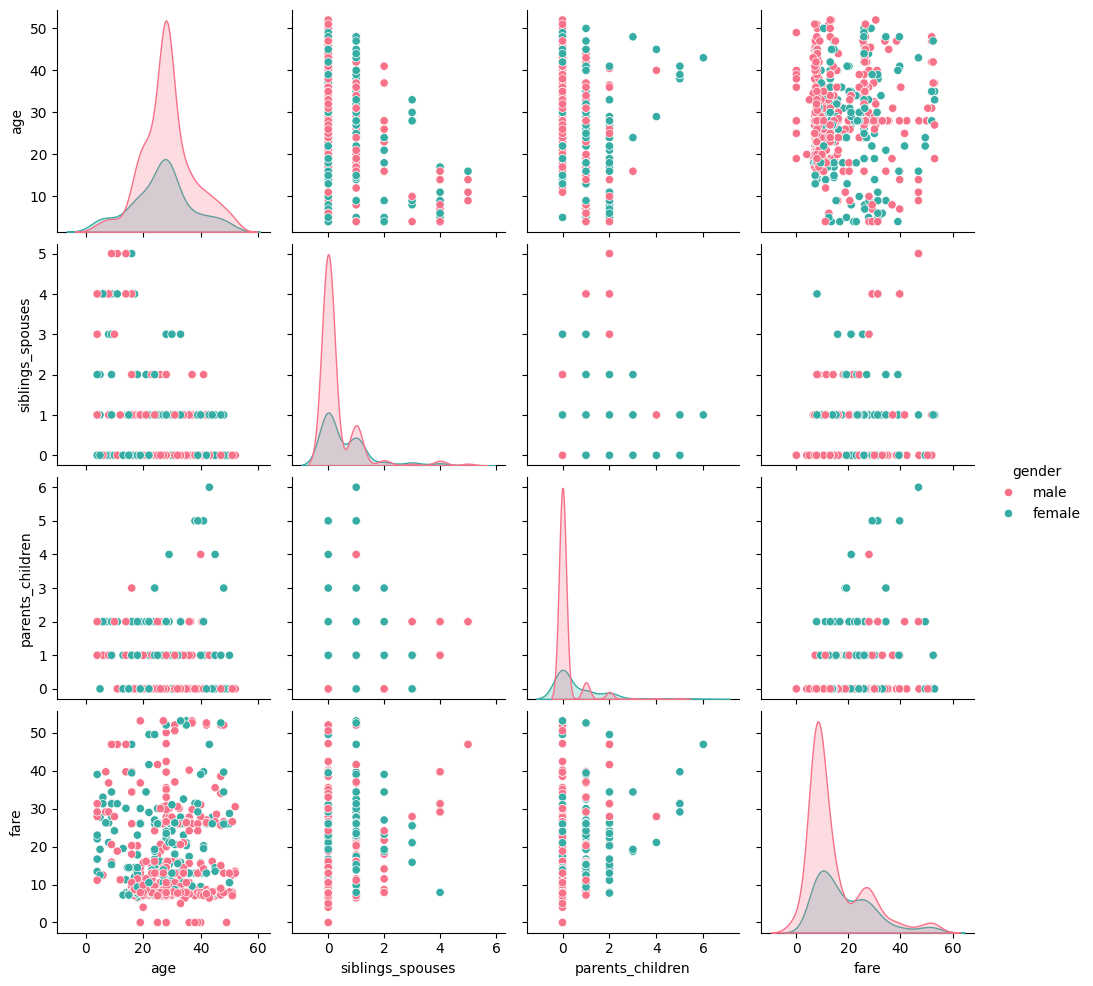

In [58]:
sns.pairplot(data, hue='gender', palette='husl')
plt.show()

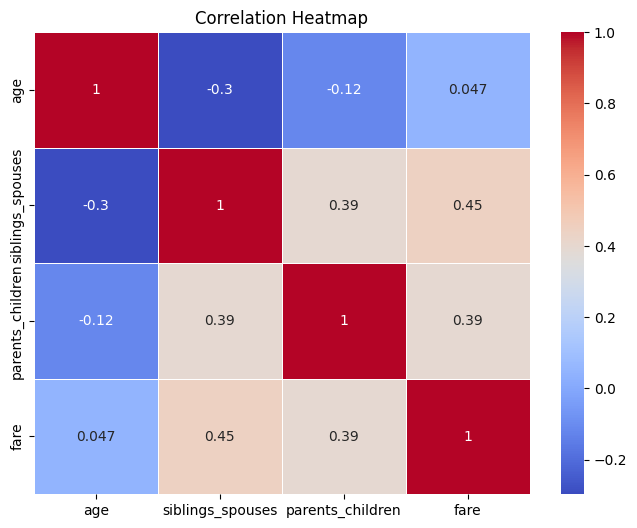

In [59]:
#1. Correlation Heatmap
plt.figure(figsize=(8,6))

corr = data.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

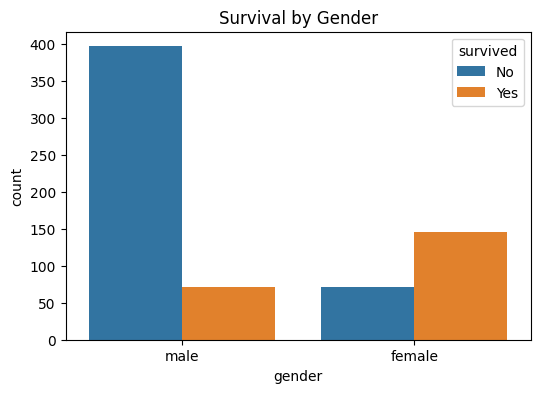

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(data=data, x='gender', hue='survived')

plt.title("Survival by Gender")
plt.show()

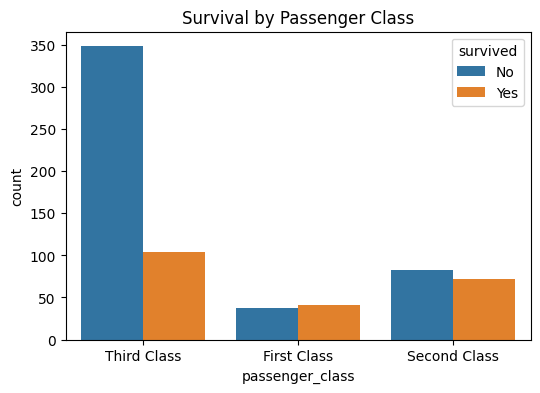

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(data=data, x='passenger_class', hue='survived')

plt.title("Survival by Passenger Class")
plt.show()

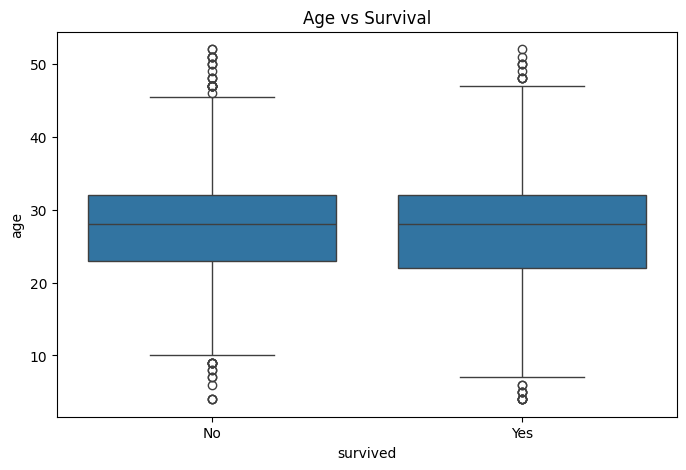

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x='survived', y='age')

plt.title("Age vs Survival")
plt.show()

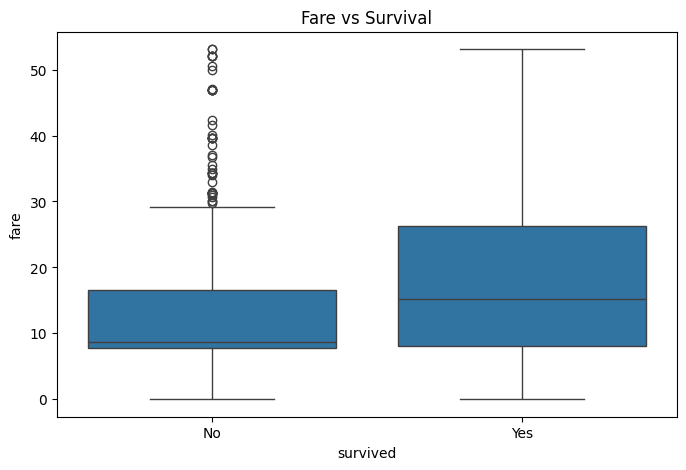

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x='survived', y='fare')

plt.title("Fare vs Survival")
plt.show()

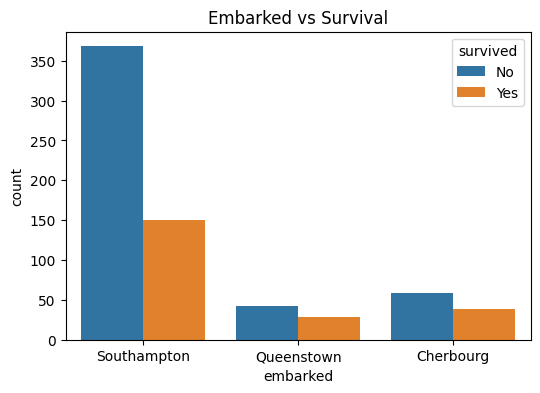

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(data=data, x='embarked', hue='survived')

plt.title("Embarked vs Survival")
plt.show()